In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("StudentsPerformance.csv")

print(df.head())



   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


# Dataset Overview

In [32]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   overall_score                1000 non-null   float64
 9   risk_category                1000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 78.3+ KB
None
       math score  reading score  writing score  overall_score
count  1000.00000    1000.000000    1000.000000    1000.000000
mean

# Subject-wise Performance Analysis

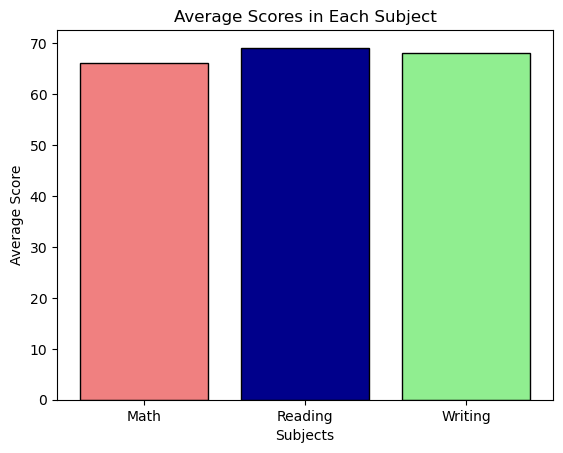

In [ ]:

avg_scores = [
    df["math score"].mean(),
    df["reading score"].mean(),
    df["writing score"].mean(),
]

subjects = ["Math", "Reading", "Writing"]

plt.bar(subjects, avg_scores, color=["lightcoral", "darkblue", "lightgreen"], edgecolor="black")
plt.title("Average Scores in Each Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.show()

# Correlation Analysis


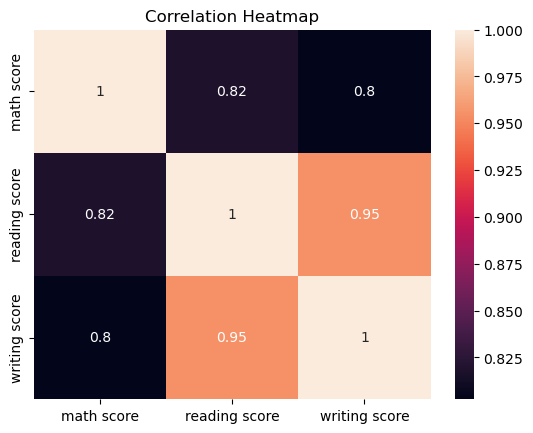

In [ ]:

corr = df[["math score","reading score","writing score"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Reading vs Writing Relationship

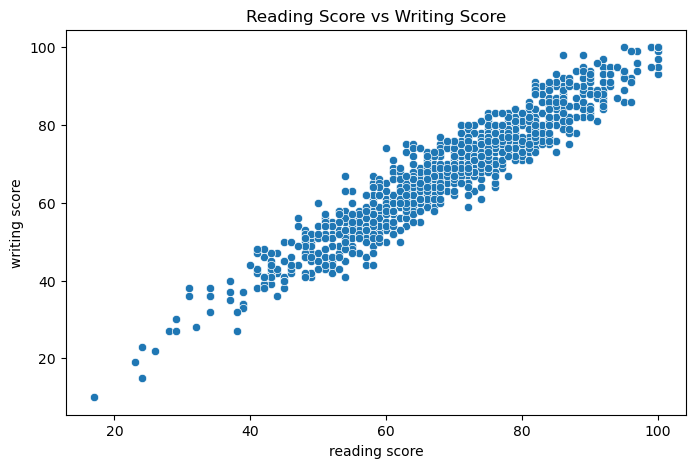

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="reading score",
    y="writing score",
    data=df
)
plt.title("Reading Score vs Writing Score")
plt.show()

# Test Preparation Impact

In [ ]:
df.groupby("test preparation course")[
    ["math score","reading score","writing score"]
].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [22]:
df["overall_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)/3

# Student Risk Assessment

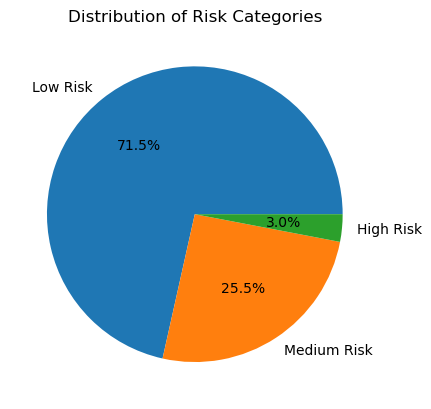

In [31]:
def classify(score):
    if score < 40:
        return "High Risk"
    elif score < 60:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_counts = df["risk_category"].value_counts()

risk_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Risk Categories")
plt.ylabel("")
plt.show()

# Key Insights

In [26]:
print(df["risk_category"].value_counts())

risk_category
Low Risk       715
Medium Risk    255
High Risk       30
Name: count, dtype: int64
